<a href="https://colab.research.google.com/github/NVHau-K14/Tuan03_ThucHanh_DeepLearning-/blob/main/ANN_NhanDangAnh_CIFAR10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Khai báo các thư viện cần thiết

In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

Khai báo nhãn và tải bộ dữ liệu

In [5]:
# Khai báo danh sách các nhãn theo yêu cầu của đề bài
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Tải dataset CIFAR10
print("Đang tải dữ liệu CIFAR-10...")
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
print("Tải dữ liệu thành công!")
print(f"Kích thước tập huấn luyện: {x_train.shape}")
print(f"Kích thước tập kiểm tra: {x_test.shape}")

Đang tải dữ liệu CIFAR-10...
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 15s 0us/step
Tải dữ liệu thành công!
Kích thước tập huấn luyện: (50000, 32, 32, 3)
Kích thước tập kiểm tra: (10000, 32, 32, 3)


Tiền xử lý dữ liệu (Pre-processing)

In [6]:
# Chuẩn hóa dữ liệu
x_train = x_train / 255.0
x_test = x_test / 255.0
print("Đã chuẩn hóa dữ liệu xong!")

Đã chuẩn hóa dữ liệu xong!


Xây dựng cấu trúc mô hình ANN

In [7]:
# Khởi tạo mô hình
model = models.Sequential([
    # Lớp Flatten: Duỗi mảng ảnh 3D (32, 32, 3) thành vector 1D (3072)
    layers.Flatten(input_shape=(32, 32, 3)),

    # Các lớp ẩn (Hidden Layers)
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),

    # Lớp đầu ra (Output Layer): 10 node cho 10 class, dùng softmax
    layers.Dense(10, activation='softmax')
])

# Hiển thị tóm tắt cấu trúc mạng nơ-ron
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

Biên dịch mô hình (Compile)

In [8]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
print("Đã biên dịch mô hình, sẵn sàng để huấn luyện!")

Đã biên dịch mô hình, sẵn sàng để huấn luyện!


Huấn luyện mô hình (Training)

In [ ]:
print("Bắt đầu huấn luyện mô hình...")
history = model.fit(x_train, y_train, epochs=50, validation_data=(x_test, y_test))

Đánh giá mô hình (Evaluation)

In [13]:
print("\nĐánh giá mô hình trên tập Test:")
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'\nĐộ chính xác trên tập kiểm tra (Test Accuracy): {test_acc*100:.2f}%')


Đánh giá mô hình trên tập Test:
313/313 - 1s - 3ms/step - accuracy: 0.4937 - loss: 1.7634

Độ chính xác trên tập kiểm tra (Test Accuracy): 49.37%


Chạy thử và trực quan hóa dự đoán

Saving airplane.jpg to airplane.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step


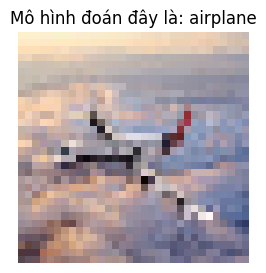

In [14]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# 1. Hiện nút chọn ảnh từ máy tính của bạn
uploaded = files.upload()

for file_name in uploaded.keys():
    # 2. Đọc ảnh và tự động đổi kích thước (resize) về 32x32 pixel
    img = image.load_img(file_name, target_size=(32, 32))

    # 3. Chuyển ảnh thành mảng số và chuẩn hóa về khoảng [0, 1] như lúc train
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0) # Thêm chiều dữ liệu (batch size)

    # 4. Đưa vào mô hình để dự đoán
    prediction = model.predict(img_array)
    predicted_label = np.argmax(prediction)

    # 5. Hiển thị ảnh và kết quả dự đoán của mô hình
    plt.figure(figsize=(3, 3))
    plt.imshow(img)
    plt.title(f"Mô hình đoán đây là: {class_names[predicted_label]}")
    plt.axis('off')
    plt.show()